## Data Preprocessing

In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split



import warnings
warnings.filterwarnings('ignore')

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [43]:
# Load Data 
df = pd.read_csv('ssti_features_all.csv')

# Drop Payload Column
df.drop(columns=['payload'], inplace=True)
df.head()



,payload_length,special_char_ratio,count_double_brace,count_dollar_brace,count_hash_brace,count_percent_brace,count_erb,delimiter_family_count,max_bracket_depth,has_dunder_chain,has_exec_tokens,has_java_reflection,has_flask_objects,has_arithmetic_operation,has_string_operation,count_method_calls,count_dots,label
0,14,0.714286,1,0,0,0,0,1,2,0,0,0,0,1,0,0,0,1
1,16,0.625000,1,0,0,0,0,1,2,0,0,0,0,1,0,0,0,1
2,7,0.714286,1,0,0,0,0,1,2,0,0,0,0,1,0,0,0,1
3,26,0.346154,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
4,9,0.777778,1,0,0,0,0,1,2,0,0,0,0,0,0,0,0,1


In [44]:
#  SPLIT INTO INPUTS (X) AND ANSWER (y)
x = df.drop(columns=['label'])
y = df.label

# Split Train and Test Data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 15)


In [34]:

scaler = StandardScaler()
x_train["payload_length"] = scaler.fit_transform(x_train[["payload_length"]])
x_test["payload_length"]  = scaler.transform(x_test[["payload_length"]])


print(x_train[["payload_length"]].head()) 

     payload_length
454        0.436338
270       -0.931570
315       -0.589593
526       -0.281814
664       -0.692186


## Modeling

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score
)

""" def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    # Classification report: precision, recall, F1 per class
    print(classification_report(y_test, y_pred))

    # ROC-AUC (the most important single number)
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    print(f"ROC-AUC (macro OVR): {auc:.4f}")

    # Confusion matrix heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion matrix — {name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show() """

def evaluate_model(name, model, X_test, y_test, pos_label=1, multiclass=False):
    """Print report + ROC-AUC and show a confusion matrix for a fitted model.
    pos_label  : which class counts as 'positive' (binary only)
    multiclass : set True when you have 3+ classes
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))

    if multiclass:
        auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    else:
        auc = roc_auc_score(y_test, y_prob[:, pos_label])   # positive-class column
    print(f"ROC-AUC: {auc:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion matrix — {name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.show()

In [46]:

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression



def train_logistic_regression(X_train, y_train):
    # Logistic Regression barely needs tuning; good defaults are enough.
    # class_weight="balanced" makes errors on rare attack classes count
    # more, so the model doesn't just learn to predict the majority class.
    # max_iter is raised so the optimizer has time to converge.
    model = LogisticRegression(max_iter=1000,  class_weight="balanced",n_jobs=-1)
    model.fit(X_train, y_train)
    return model


def train_naive_bayes(X_train, y_train):
    # GaussianNB has essentially nothing worth tuning.
    # It assumes features are independent, which isn't true for network
    # traffic, so expect it to be the weakest model — a useful baseline
    # to compare the others against.
    model = GaussianNB()
    model.fit(X_train, y_train)
    return model


In [ ]:

from sklearn.tree import DecisionTreeClassifier


def train_decision_tree(X_train, y_train):
    # The hyperparameters we let the search try.
    # This dict is the important part — it defines the options being optimized.
    params = {
        "max_depth": [None, 10, 20, 40],     # how deep the tree can grow
        "min_samples_leaf": [1, 5, 20],      # min samples in a leaf (controls overfitting)
        "criterion": ["gini", "entropy"],    # how splits are scored
    }

    search = RandomizedSearchCV(
        DecisionTreeClassifier(class_weight="balanced", random_state=42),
        params,
        n_iter=8,              # try 8 random combinations from the grid above
        scoring="f1_macro",    # IMPORTANT: optimize macro-F1, not accuracy,
                               # so rare attacks are weighted equally
        cv=cv,                 # the shared 3-fold stratified CV
        n_jobs=-1,             # use all CPU cores (speed only)
        random_state=42        # reproducible results
    )
    search.fit(X_train, y_train)          # runs CV, then refits the best model on all data
    print("best params:", search.best_params_)
    return search.best_estimator_         # already fitted and ready to predict


In [48]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

def train_svm(X_train, y_train):

    params = {
        "C": [0.1, 1, 10],                 # regularization strength
        "gamma": ["scale", 0.01, 0.1],     # how far one sample's influence reaches
    }
    search = RandomizedSearchCV(
        # probability=True lets SVM output probabilities so ROC-AUC works
        # (it's slower, but needed for a fair comparison).
        SVC(kernel="rbf", probability=True,
            class_weight="balanced", random_state=42),
        params, n_iter=6, scoring="f1_macro", cv=cv,
        n_jobs=-1, random_state=42
    )
    search.fit(X_train, y_train)
    print("best params:", search.best_params_)
    return search.best_estimator_

def train_knn(X_train, y_train):
    params = {
        "n_neighbors": [3, 5, 11, 21],          # how many neighbors vote
        "weights": ["uniform", "distance"],     # equal vote vs. closer = stronger vote
    }
    search = RandomizedSearchCV(
        KNeighborsClassifier(n_jobs=-1),
        params, n_iter=6, scoring="f1_macro", cv=cv,
        n_jobs=-1, random_state=42
    )
    search.fit(X_train, y_train)
    print("best params:", search.best_params_)
    return search.best_estimator_
    

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def train_random_forest(X_train, y_train):
    params = {
        "n_estimators": [200, 400, 600],     # number of trees
        "max_depth": [None, 20, 40],         # depth of each tree
        "min_samples_leaf": [1, 2, 5],       # leaf size (overfitting control)
        "max_features": ["sqrt", "log2"],    # features considered per split
    }
    search = RandomizedSearchCV(
        # "balanced_subsample" recomputes class weights for each tree's
        # bootstrap sample — the RF-friendly version of "balanced".
        RandomForestClassifier(class_weight="balanced_subsample",
                               random_state=42, n_jobs=-1),
        params, n_iter=10, scoring="f1_macro", cv=cv,
        n_jobs=-1, random_state=42
    )
    search.fit(X_train, y_train)
    print("best params:", search.best_params_)
    return search.best_estimator_


def train_xgboost(X_train, y_train):
    params = {
        "n_estimators": [300, 500, 800],         # number of boosting rounds
        "max_depth": [4, 6, 8],                  # tree depth
        "learning_rate": [0.03, 0.1, 0.2],       # step size per round
        "subsample": [0.8, 1.0],                 # row sampling per tree
        "colsample_bytree": [0.8, 1.0],          # feature sampling per tree
    }
    search = RandomizedSearchCV(
        # tree_method="hist" is the fast histogram-based algorithm,
        # important for a dataset this size.
        XGBClassifier(tree_method="hist", eval_metric="logloss",
                      n_jobs=-1, random_state=42),
        params, n_iter=12, scoring="f1_macro", cv=cv,
        n_jobs=-1, random_state=42
    )
    search.fit(X_train, y_train)
    print("best params:", search.best_params_)
    return search.best_estimator_



best params: {'min_samples_leaf': 5, 'max_depth': 10, 'criterion': 'entropy'}
best params: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
best params: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
best params: {'weights': 'distance', 'n_neighbors': 3}
best params: {'gamma': 0.1, 'C': 10}

===== Naive Bayes =====
              precision    recall  f1-score   support

           0       0.71      0.99      0.83       102
           1       0.98      0.56      0.72        94

    accuracy                           0.79       196
   macro avg       0.85      0.78      0.77       196
weighted avg       0.84      0.79      0.77       196

ROC-AUC: 0.9074


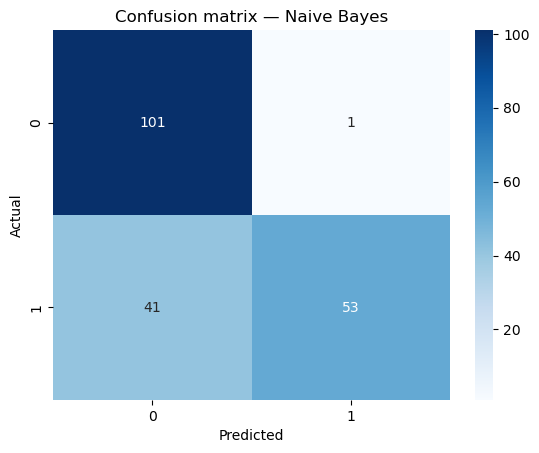


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.88      0.97      0.93       102
           1       0.96      0.86      0.91        94

    accuracy                           0.92       196
   macro avg       0.92      0.92      0.92       196
weighted avg       0.92      0.92      0.92       196

ROC-AUC: 0.9454


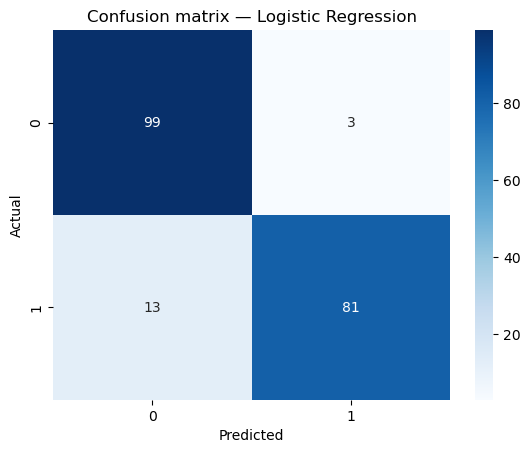


===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       102
           1       0.96      0.90      0.93        94

    accuracy                           0.93       196
   macro avg       0.94      0.93      0.93       196
weighted avg       0.93      0.93      0.93       196

ROC-AUC: 0.9622


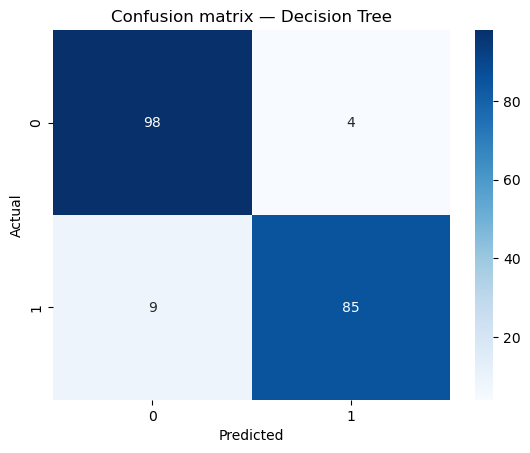


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       102
           1       0.97      0.91      0.94        94

    accuracy                           0.94       196
   macro avg       0.95      0.94      0.94       196
weighted avg       0.94      0.94      0.94       196

ROC-AUC: 0.9811


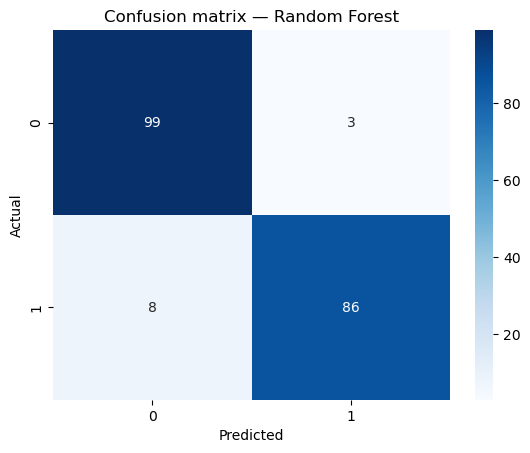


===== XGBoost =====
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       102
           1       0.99      0.93      0.96        94

    accuracy                           0.96       196
   macro avg       0.96      0.96      0.96       196
weighted avg       0.96      0.96      0.96       196

ROC-AUC: 0.9645


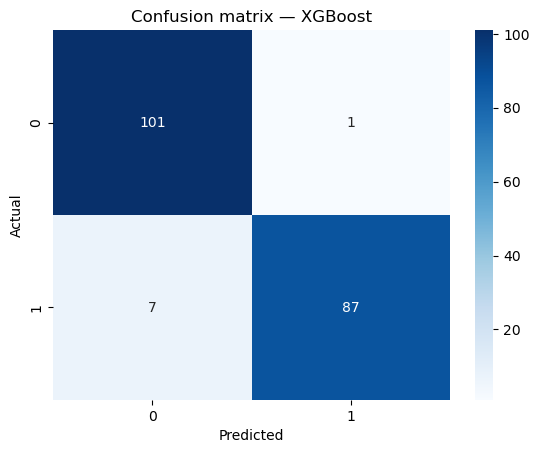


===== KNN =====
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       102
           1       0.93      0.83      0.88        94

    accuracy                           0.89       196
   macro avg       0.89      0.89      0.89       196
weighted avg       0.89      0.89      0.89       196

ROC-AUC: 0.9374


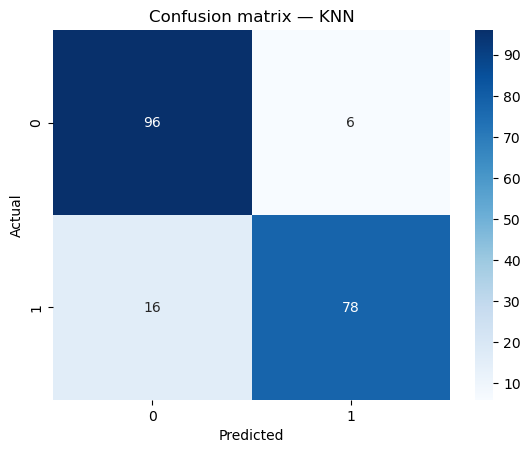


===== SVM =====
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       102
           1       0.95      0.87      0.91        94

    accuracy                           0.92       196
   macro avg       0.92      0.92      0.92       196
weighted avg       0.92      0.92      0.92       196

ROC-AUC: 0.9578


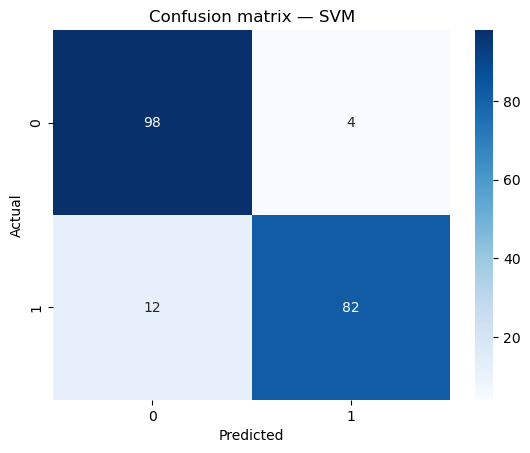

In [59]:
class_names = ['BENIGN', 'SSTI_Vulnerable']

# Train each model. Each function returns a fitted, ready-to-use model.
models = {
    "Naive Bayes":         train_naive_bayes(x_train, y_train),
    "Logistic Regression": train_logistic_regression(x_train, y_train),
    "Decision Tree":       train_decision_tree(x_train, y_train),
    "Random Forest":       train_random_forest(x_train, y_train),
    "XGBoost":             train_xgboost(x_train, y_train),
    "KNN":                 train_knn(x_train, y_train),
    "SVM":                 train_svm(x_train, y_train),
}

# Evaluate each trained model with the same function, so the comparison is fair.
for name, mdl in models.items():
    evaluate_model(name, mdl, x_test, y_test) 

In [4]:
"""
Reusable classical-ML modeling pipeline.
========================================

Design goal: point this at ANY tabular dataset with a label column and get
a fair, reproducible comparison of 7 classifiers. Works for binary problems
(SSTI vs BENIGN) and multiclass problems (CICIDS2017 attack families)
without changing the code — the evaluation adapts automatically.

Pipeline shape (always the same order, because order is what protects
against data leakage):

    load_data  ->  split_data  ->  scale_features  ->  train  ->  evaluate

Why the order matters:
  - Split BEFORE scaling. The scaler is fitted on training data only, then
    reused to transform the test set. Fitting on the full dataset would leak
    test-set statistics (mean/std) into training — a classic reviewer catch.
  - Stratify the split so rare attack classes appear in both train and test
    at the same ratio as in the full dataset.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, f1_score
)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# ======================================================================
# GLOBAL CONFIG — one place for every "magic number"
# ======================================================================
# Keeping these at the top means the whole experiment is reproducible
# from a single spot, which is what you cite in the paper's methodology.

RANDOM_STATE = 42     # one seed everywhere (split, CV, every model)
TEST_SIZE    = 0.2    # 80/20 train/test split

# Shared CV strategy for every tuned model.
# StratifiedKFold keeps class proportions identical in each fold — critical
# when some attack classes are rare. 3 folds instead of 5 because the
# datasets are large and 5 folds nearly doubles tuning time for little gain.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)





In [8]:
def preprocess_ssti(csv_path="ssti_features_all.csv"):
    """
    Preprocessing customized for the SSTI feature dataset.

    Assumptions specific to this dataset:
      - raw payload text lives in a column named 'payload' (CNN/BiLSTM
        track input — dropped here, the tabular track uses only the
        engineered numeric features)
      - the label column is named 'label'
      - binary problem: BENIGN vs SSTI

    Steps (fixed order = leakage defense):
      load -> drop payload -> encode label -> stratified split -> scale

    Returns:
      x_train, x_test, y_train, y_test : model-ready arrays
      class_names : label names for reports/plots (None if already numeric)
      scaler      : fitted StandardScaler — reuse on any future data,
                    never refit
    """
    # --- load ---
    df = pd.read_csv(csv_path)

    # --- drop the raw payload column ---
    # errors="ignore" so the function doesn't crash if a future version
    # of the dataset builder stops writing this column.
    df = df.drop(columns=["payload"], errors="ignore")

    # --- inputs (X) and answer (y) ---
    x = df.drop(columns=["label"])
    y = df["label"]

    # --- encode text labels to integers (XGBoost requires it) ---
    class_names = None
    if y.dtype == object:
        le = LabelEncoder()
        y = pd.Series(le.fit_transform(y), name="label")
        class_names = list(le.classes_)
        print("Label encoding:", dict(zip(class_names, range(len(class_names)))))

    # --- stratified split ---
    # stratify=y keeps the BENIGN/SSTI ratio identical in train and test.
    # Critical here: the test set is only ~72 rows, so an unstratified
    # split visibly skews every metric.
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )

    # --- scale: fit on TRAIN ONLY, transform both ---
    # Required for SVM / KNN / Logistic Regression (distance- and
    # gradient-based); harmless for the tree models.
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    # Sanity check — eyeball before training:
    print("Train shape:", x_train.shape, "| Test shape:", x_test.shape)
    print("Train class counts:\n", y_train.value_counts())

    return x_train, x_test, y_train, y_test, class_names, scaler

In [12]:


# ======================================================================
# STEP 2 — TRAINING FUNCTIONS (one per model, training ONLY)
# ======================================================================
# Each function does exactly one thing: return a fitted model.
# No evaluation, no plotting — that separation is what makes the
# comparison fair (every model is judged by the same evaluate_model).

# --- Simple baselines: no tuning needed ------------------------------

def train_naive_bayes(X_train, y_train):
    # GaussianNB has essentially nothing worth tuning. It assumes feature
    # independence, which is false for both network traffic and payload
    # features, so expect it to be the weakest model — its job is to be
    # the floor the other models must beat.
    model = GaussianNB()
    model.fit(X_train, y_train)
    return model


def train_logistic_regression(X_train, y_train):
    # class_weight="balanced" makes mistakes on rare classes cost more,
    # so the model can't win by always predicting the majority class.
    # max_iter raised so the optimizer converges on scaled features.
    model = LogisticRegression(
        max_iter=1000, class_weight="balanced", n_jobs=-1
    )
    model.fit(X_train, y_train)
    return model


# --- Light tuning -----------------------------------------------------

def train_decision_tree(X_train, y_train):
    # The params dict is the experiment: these are the knobs being searched.
    params = {
        "max_depth": [None, 10, 20, 40],   # how deep the tree may grow
        "min_samples_leaf": [1, 5, 20],    # bigger leaves = less overfitting
        "criterion": ["gini", "entropy"],  # how splits are scored
    }
    search = RandomizedSearchCV(
        DecisionTreeClassifier(class_weight="balanced",
                               random_state=RANDOM_STATE),
        params,
        n_iter=8,
        scoring="f1_macro",   # macro-F1, not accuracy, so rare classes
                              # count equally — the honest metric for
                              # imbalanced security data
        cv=cv, n_jobs=-1, random_state=RANDOM_STATE
    )
    search.fit(X_train, y_train)
    print("  best params:", search.best_params_)
    return search.best_estimator_


# --- Slow models ------------------------------------------------------
# NOTE: on very large datasets (CICIDS2017 full), tune these on a
# stratified subsample first, then refit the best params on all data.
# On the SSTI dataset (~hundreds of rows) they run fine as-is.

def train_svm(X_train, y_train):
    params = {
        "C": [0.1, 1, 10],              # regularization strength
        "gamma": ["scale", 0.01, 0.1],  # reach of one sample's influence
    }
    search = RandomizedSearchCV(
        # probability=True is slower but required: without it SVM can't
        # output probabilities and ROC-AUC (our headline metric) fails.
        SVC(kernel="rbf", probability=True,
            class_weight="balanced", random_state=RANDOM_STATE),
        params, n_iter=6, scoring="f1_macro", cv=cv,
        n_jobs=-1, random_state=RANDOM_STATE
    )
    search.fit(X_train, y_train)
    print("  best params:", search.best_params_)
    return search.best_estimator_


def train_knn(X_train, y_train):
    params = {
        "n_neighbors": [3, 5, 11, 21],       # how many neighbors vote
        "weights": ["uniform", "distance"],  # equal vote vs closer = louder
    }
    search = RandomizedSearchCV(
        KNeighborsClassifier(n_jobs=-1),
        params, n_iter=6, scoring="f1_macro", cv=cv,
        n_jobs=-1, random_state=RANDOM_STATE
    )
    search.fit(X_train, y_train)
    print("  best params:", search.best_params_)
    return search.best_estimator_


# --- Models that genuinely benefit from tuning ------------------------

def train_random_forest(X_train, y_train):
    params = {
        "n_estimators": [200, 400, 600],   # number of trees
        "max_depth": [None, 20, 40],       # depth of each tree
        "min_samples_leaf": [1, 2, 5],     # overfitting control
        "max_features": ["sqrt", "log2"],  # features considered per split
    }
    search = RandomizedSearchCV(
        # "balanced_subsample" recomputes class weights per bootstrap
        # sample — the RF-appropriate version of "balanced".
        RandomForestClassifier(class_weight="balanced_subsample",
                               random_state=RANDOM_STATE, n_jobs=-1),
        params, n_iter=10, scoring="f1_macro", cv=cv,
        n_jobs=-1, random_state=RANDOM_STATE
    )
    search.fit(X_train, y_train)
    print("  best params:", search.best_params_)
    return search.best_estimator_


def train_xgboost(X_train, y_train):
    params = {
        "n_estimators": [300, 500, 800],    # boosting rounds
        "max_depth": [4, 6, 8],             # tree depth
        "learning_rate": [0.03, 0.1, 0.2],  # step size per round
        "subsample": [0.8, 1.0],            # row sampling per tree
        "colsample_bytree": [0.8, 1.0],     # feature sampling per tree
    }

    # Pick the eval metric from the data itself, so the same function is
    # correct for the binary SSTI problem ("logloss") and the multiclass
    # CICIDS2017 problem ("mlogloss") with no manual switching.
    # Note: since we don't pass an eval_set, this metric doesn't drive
    # training — hyperparameters are chosen by scoring="f1_macro" below.
    # It's set explicitly anyway so the configuration is self-documenting
    # and defensible in the paper.
    n_classes = len(np.unique(y_train))
    metric = "logloss" if n_classes == 2 else "mlogloss"

    search = RandomizedSearchCV(
        # tree_method="hist" = fast histogram algorithm, matters at
        # CICIDS2017 scale.
        XGBClassifier(tree_method="hist", eval_metric=metric,
                      n_jobs=-1, random_state=RANDOM_STATE),
        params, n_iter=12, scoring="f1_macro", cv=cv,
        n_jobs=-1, random_state=RANDOM_STATE
    )
    search.fit(X_train, y_train)
    print("  best params:", search.best_params_)
    return search.best_estimator_


# ======================================================================
# STEP 3 — EVALUATION (one function, every model, same rules)
# ======================================================================

def evaluate_model(name, model, X_test, y_test, class_names=None):
    """
    Evaluate one fitted model and return its metrics as a dict.

    Handles binary AND multiclass automatically:
      - Binary (SSTI): roc_auc_score wants ONLY the positive-class
        probability, i.e. y_prob[:, 1].
      - Multiclass (CICIDS2017): it wants the full probability matrix
        plus multi_class='ovr'.
    Getting this wrong is a silent bug — sklearn raises an error in one
    direction but in the other it can compute a misleading number.

    Returns the metrics (instead of only printing) so a comparison table
    can be built across models — that table becomes the results section
    of the paper.
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=class_names))

    n_classes = len(np.unique(y_test))
    if n_classes == 2:
        auc = roc_auc_score(y_test, y_prob[:, 1])
    else:
        auc = roc_auc_score(y_test, y_prob,
                            multi_class="ovr", average="macro")
    print(f"ROC-AUC: {auc:.4f}")

    # Confusion matrix heatmap — labeled with real class names when known.
    ticks = class_names if class_names is not None else "auto"
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=ticks, yticklabels=ticks)
    plt.title(f"Confusion matrix — {name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

    return {
        "model": name,
        "roc_auc": auc,
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
    }



  



Train shape: (781, 17) | Test shape: (196, 17)
Train class counts:
 label
0    400
1    381
Name: count, dtype: int64

Training Naive Bayes ...

Training Logistic Regression ...

Training Decision Tree ...
  best params: {'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'gini'}

Training Random Forest ...
  best params: {'n_estimators': 400, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 40}

Training XGBoost ...
  best params: {'subsample': 1.0, 'n_estimators': 800, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Training KNN ...
  best params: {'weights': 'uniform', 'n_neighbors': 3}

Training SVM ...
  best params: {'gamma': 0.1, 'C': 10}

  Naive Bayes
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       100
           1       1.00      0.57      0.73        96

    accuracy                           0.79       196
   macro avg       0.85      0.79      0.78       196
weighted avg       0.85     

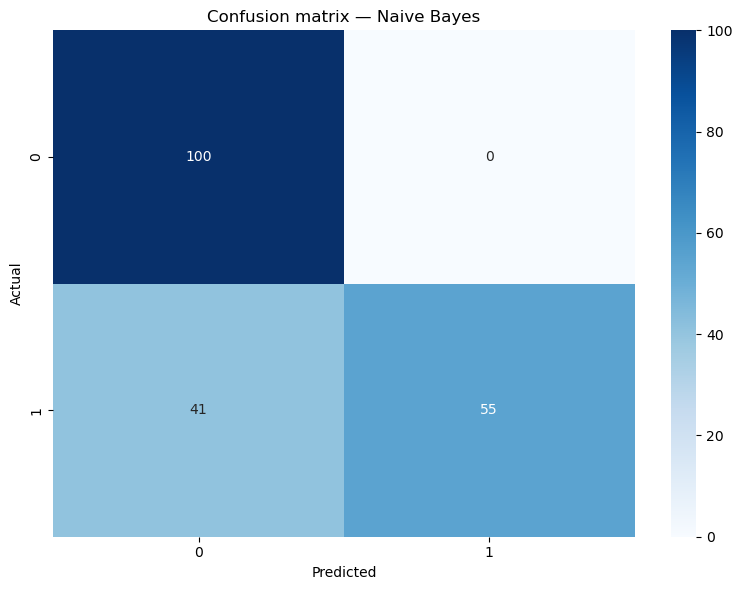


  Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       100
           1       0.98      0.89      0.93        96

    accuracy                           0.93       196
   macro avg       0.94      0.93      0.93       196
weighted avg       0.94      0.93      0.93       196

ROC-AUC: 0.9797


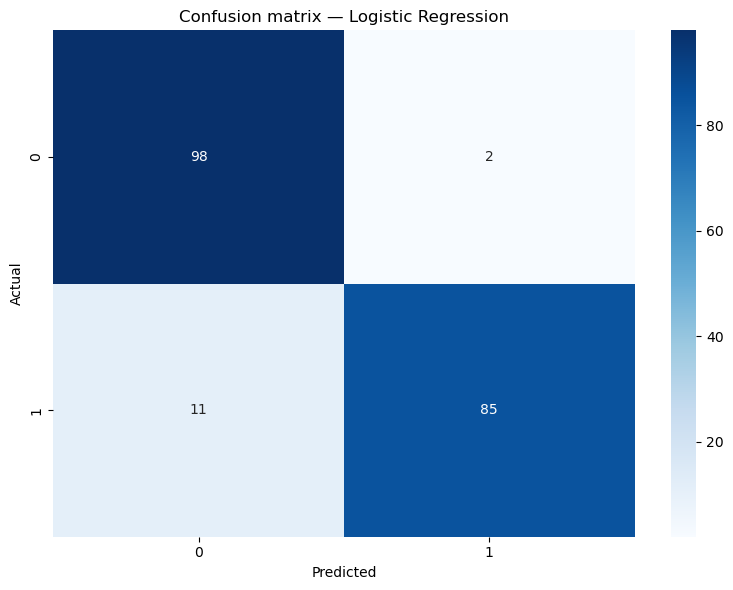


  Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       100
           1       0.96      0.98      0.97        96

    accuracy                           0.97       196
   macro avg       0.97      0.97      0.97       196
weighted avg       0.97      0.97      0.97       196

ROC-AUC: 0.9693


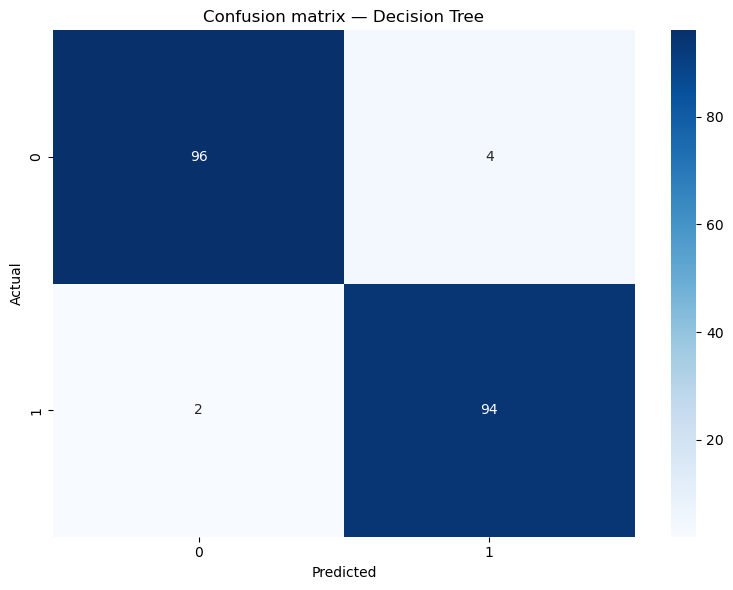


  Random Forest
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       100
           1       0.98      0.94      0.96        96

    accuracy                           0.96       196
   macro avg       0.96      0.96      0.96       196
weighted avg       0.96      0.96      0.96       196

ROC-AUC: 0.9974


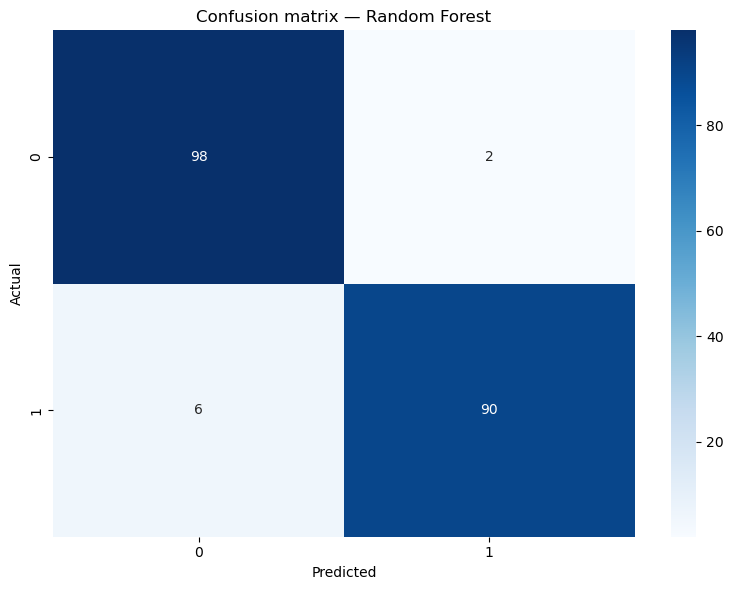


  XGBoost
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       100
           1       0.99      0.95      0.97        96

    accuracy                           0.97       196
   macro avg       0.97      0.97      0.97       196
weighted avg       0.97      0.97      0.97       196

ROC-AUC: 0.9897


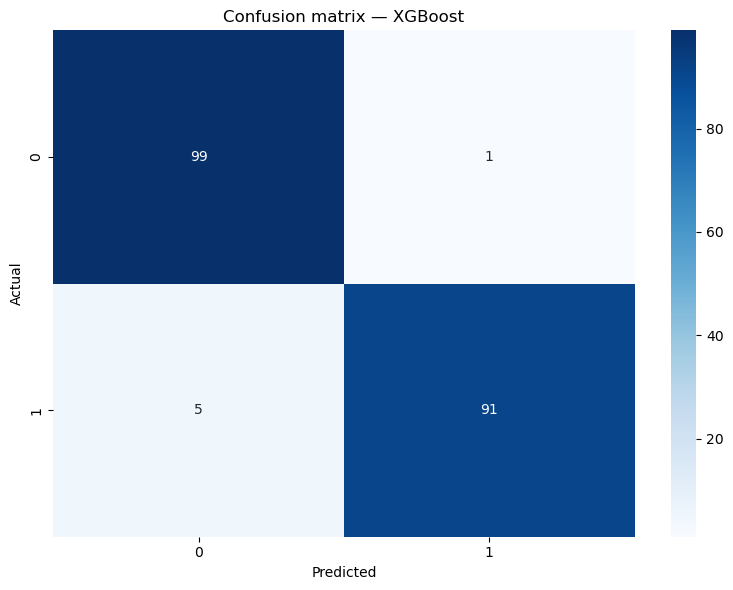


  KNN
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       100
           1       1.00      0.91      0.95        96

    accuracy                           0.95       196
   macro avg       0.96      0.95      0.95       196
weighted avg       0.96      0.95      0.95       196

ROC-AUC: 0.9825


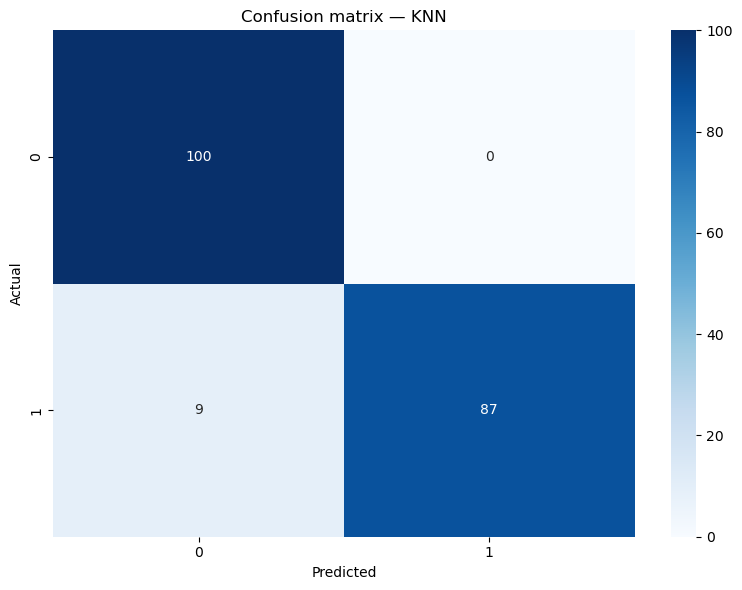


  SVM
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       100
           1       1.00      0.94      0.97        96

    accuracy                           0.97       196
   macro avg       0.97      0.97      0.97       196
weighted avg       0.97      0.97      0.97       196

ROC-AUC: 0.9814


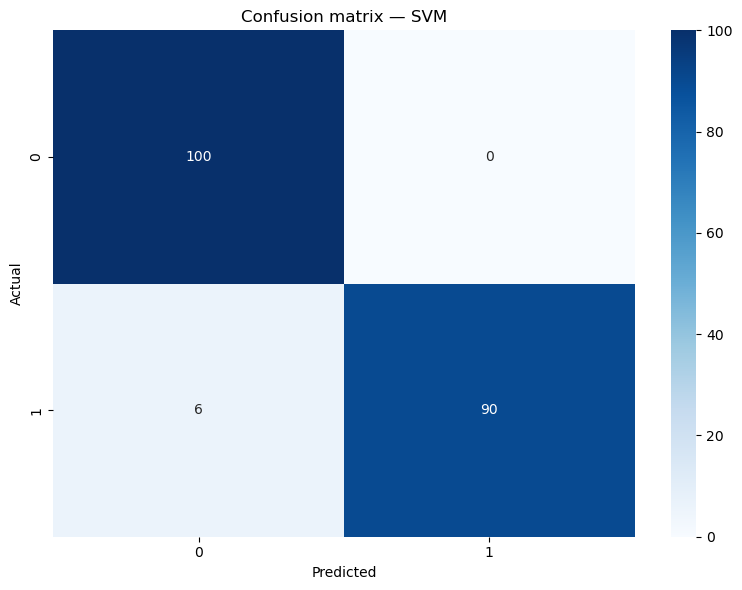


  FINAL COMPARISON
              model  roc_auc  f1_macro
      Decision Tree 0.969271  0.969385
            XGBoost 0.989688  0.969337
                SVM 0.981354  0.969308
      Random Forest 0.997396  0.959116
                KNN 0.982500  0.953879
Logistic Regression 0.979688  0.933380
        Naive Bayes 0.937292  0.779176


In [13]:
# ======================================================================
# STEP 4 — ORCHESTRATION: run the whole experiment in one call
# ======================================================================

# Registry of every model in the comparison. Adding a new model to the
# study = one train_*() function + one line here. Nothing else changes.
MODEL_TRAINERS = {
    "Naive Bayes":         train_naive_bayes,
    "Logistic Regression": train_logistic_regression,
    "Decision Tree":       train_decision_tree,
    "Random Forest":       train_random_forest,
    "XGBoost":             train_xgboost,
    "KNN":                 train_knn,
    "SVM":                 train_svm,
}

def run_pipeline(preprocess_fn, csv_path, models_to_run=None):
    """
    The full experiment: preprocess -> train all -> evaluate all.

    preprocess_fn: the dataset-specific preprocessing function to use
    (e.g. preprocess_ssti today, preprocess_cicids later). Each dataset
    gets its own function with its own quirks; the pipeline just calls
    whichever one it's handed. It must return, in this order:
        x_train, x_test, y_train, y_test, class_names, scaler

    models_to_run: optional list of names from MODEL_TRAINERS, so you can
    do a quick run with just ["Naive Bayes", "Decision Tree"] while
    iterating on features, then run everything for the final results.

    Returns (models, results_df, scaler) so you can inspect any fitted
    model afterwards (e.g. feature importances, SHAP) and reuse the
    scaler on new data.
    """
    # --- data ---
    # All dataset-specific logic lives inside preprocess_fn; the pipeline
    # only depends on the agreed return order.
    (x_train, x_test, y_train, y_test,
     class_names, scaler) = preprocess_fn(csv_path)

    # --- train ---
    if models_to_run is None:
        models_to_run = list(MODEL_TRAINERS.keys())

    models = {}
    for name in models_to_run:
        print(f"\nTraining {name} ...")
        models[name] = MODEL_TRAINERS[name](x_train, y_train)

    # --- evaluate ---
    results = []
    for name, mdl in models.items():
        results.append(
            evaluate_model(name, mdl, x_test, y_test, class_names)
        )

    # Final comparison table, best model first — this is the headline
    # table for the paper's results section.
    results_df = (pd.DataFrame(results)
                    .sort_values("f1_macro", ascending=False)
                    .reset_index(drop=True))
    print("\n" + "="*50)
    print("  FINAL COMPARISON")
    print("="*50)
    print(results_df.to_string(index=False))

    return models, results_df, scaler


# ======================================================================
# USAGE
# ======================================================================
if __name__ == "__main__":
    # SSTI dataset (binary):
    models, results, scaler = run_pipeline(preprocess_ssti,
                                           "ssti_features_all.csv")

    # Quick iteration — only fast models while refining features:
    # models, results, scaler = run_pipeline(
    #     preprocess_ssti, "ssti_features_all.csv",
    #     models_to_run=["Naive Bayes", "Logistic Regression", "Decision Tree"]
    # )

    # CICIDS2017 later — write preprocess_cicids() with that dataset's
    # quirks (the ' Label' column, infinity values), then:
    # models, results, scaler = run_pipeline(preprocess_cicids,
    #                                        "cicids2017_clean.csv")
